# ITI5201 Machine Learning Assignment 2

#### Eddy, 33495068 

## Document Clustering

**1.1** Derive Expectation and Maximization steps of the hard-EM algorithm for Document Clustering, in a markdown cell (ideally using Latex for clean typesetting). In particular, include all model parameters that should be learnt and the exact expression (using the same math convention that we saw in the Module 4) that should be used to update these parameters during the learning process (ie., E step, M step and assignments).

In document clustering, we have a collection of documents which are represented by $(d_1, d_2, ..., d_n)$ Since usually in document clustering we have incomplete datathey can be considered as latent variables $(z_1,z_2,...,z_n)$ which are unseen. Since this is a document clustering zn is the cluster assignment for the nth documents


We assume that $\theta$ is the collection of the parameter then we got = $\theta = (\varphi, \mu_1, ..., \mu_k)$ then we define both parameters in $\theta$ 

$$\varphi = (\varphi_1, \varphi_2, ... , \varphi_K) \text{ is the cluster proportion with } \varphi_k >= 0 \text{ and } \Sigma_{k=1}^{K} \text{ with } \varphi_K = 1 \\
\mu_k = (\mu_{k,1}, \mu_{k,2}, ... , \mu_{k,A} ) \text{ is the word proportion for each cluster with } \mu_{k,w} > = 0 \text{ and } \Sigma_{w \in A} \mu_{k,w} = 1$$


We assume a document and it's cluster label are known, the joint likelihood of generating a document d and its cluster label k is =

$$p(k,d) = p(k)p(d|k) = \varphi{k}\prod_{w \in d}\mu{k,w} = \varphi\prod_{w \in A} \mu_{k,w}^{c(w,d)}$$

Therefore the likelihood formula is

$$
p(d_{1}, d_{2}, ... , d_{N}) = \Pi_{n=1}^{N}p(d_{n}) = \Pi_{n=1}^{N}\Sigma_{k=1}^{K}p(d_{n},z_{n} = k) = \Pi_{n=1}^{N}\Sigma_{k=1}^{K}(\varphi_{k}\Pi_{w \in A}\mu_{k,w}^{c_{w,d_n}})$$

Because we don't know the cluster labels of the documents we need to represent the incompmlete data likelihood as the complete data likelihood, 
marginalized over the hidden variables $zn = p(dn,zn) = k$

Applying the logarithmic to the equation above yields =


$$lnp(d_{1}, d_{2}, ... , d_{N}) = \Sigma_{n=1}^{N}lnp(d_{n}) = \Sigma_{n=1}^{N}ln\Sigma_{k=1}^{K}p(d_{n},z_{n} = k) = \sum_{n=1}^{N}ln\sum_{k=1}^{K}(\varphi_{k}\prod_{w \in A}\mu_{k,w}^{c_{w,d_n}})$$

We can see after applying the log likelihood into the function, there's a log of sum which is hard to be optimized. To solve this problem, the EM algorithm is introduced to make it easier

First we need to define the Q function which act as a surrogate function which is a tight lower bound to $L(\theta)$ where $Q$ is

$$Q(\theta, \theta^t) <= L(\theta) and Q(\theta^t, \theta^t) = L(\theta^t)$$

Therefore we can rewrite the observed data log likelihood into:

$$l(\theta) = \sum_{n=1}^{N}ln[\sum_{zn}q_n(zn)\frac{p(x_n,z_n|\theta)}{q_n(z_n)}]$$

Apply Jensen Inequality to derive the lowerbound as log function is a concave function = 

$$l(\theta) >= \sum_{n=1}^{N}\sum_{zn}q_n(zn)ln\frac{p(x_n,z_n|\theta)}{q_n(z_n)}\\
= \sum_{n=1}^{N}\sum_{zn}q_n(z_n)(ln p(x_n,z_n|\theta) - lnq_n(z_n))\\
= \sum_{n=1}^{N}\sum_{zn}(q_n(z_n)ln p(x_n,z_n|\theta) - q_n(z_n)lnq_n(z_n))\\
= \sum_{n=1}^{N}[E_{qn}(ln p(x_n,z_n|\theta)) + H(qn))$$

Which serves as the evidence of lower bound. Then to maximize the lower bound we add the Q function which also serve as the basis for E step of the EM algorithm. $Q(\theta, {q_n})$

$$Q(\theta, q_n) = \sum_{zn} q_n(z_n)ln\frac{p(x_n, z_n|\theta)}{q_n(z_n)}\\
\text{We see that we add the q function to the equation}\\
= \sum_{zn} q_n(z_n)ln\frac{p(x_n, z_n|\theta)p(dn|\theta)}{q_n(z_n)}\\
= \sum_{zn} q_n(z_n)ln\frac{p(x_n, z_n|\theta)}{q_n(z_n)} + \sum_{zn} q_n(z_n) lnp(dn|\theta)$$

We can see that the first term of the equation is actually the Kl divergence therefore we can rewrite it as

$$ = -Kl(q_n(z_n)||p(z_n|x_n, \theta)) +  lnp(dn|\theta)$$

To maximize it set each qn to the posterior distribution of the hidden variables zn, conditioned to the current parameter $\theta$

$$q_{n}^{*} = p(z_n|x_n, \theta)$$

E step =

Find the responsibility of the cluster to get the distribution of the document with

$$ r(z_n, k) = p(z_{n,k=1}|d_n,\theta^{old})\\
=\frac{p(d_n|z_{n, k=1},\theta^{old})p(z_{n,k=1}|\theta^{old})}{\sum_{k' = 1}^{k}p(d_n|z_{n,k'=1}\theta^{old})p(z_{n,k'=1}|\theta^{old})}$$

Since this algorithm is for hard EM, then the responsibility is assigned to the biggest data among the available cluster, therefore

$$r(z_{n,k=1}) = \begin{cases}1, & k=K^*\\0, & k\neq K^*\end{cases}$$

which means 

$$k = argmaxp(z_{n,k=1}|dn,\theta^{old})$$

We move to the M step, which maximize the expected complete data log likelihood

M step = 

$$Q(\theta, \theta^{old}) = \sum_{n=1}^{N}\sum_{k=1}^{K}p(z_{n,k=1}|d_n, \theta^{old})lnp(z_{n,k=1},d_n|\theta)\\
= \sum_{n=1}^{N}\sum_{k=1}^{K}r(z_{n,k})ln(\varphi_k \prod_{w \in A}\mu_{k,w}^{c(w,d_n)})\\
= \sum_{n=1}^{N}\sum_{k=1}^{K}r(z_{n,k})(ln\varphi_k + ln\prod_{w \in A}\mu_{k,w}^{c(w,d_n)})\\
= \sum_{n=1}^{N}\sum_{k=1}^{K}r(z_{n,k})(ln\varphi_k + \sum_{w \in A}{c(w,d_n)}ln\mu_{k,w})
$$

To update $\varphi k$ the function needs to be optimized =

$$\sum_{n=1}^{N}\sum_{k=1}^{K}r(z_{n,k})ln \varphi_k, s.t. \sum_{k=1}^{K} \varphi_k = 1$$

To optimize it, we use lagrange multiplier $\lambda$ to absorb the constraint into the objective function

$$ \sum_{n=1}^{N}\sum_{k=1}^{K}r(z_{n,k})ln \varphi_k - \lambda(\sum_{k=1}^{K}\varphi_k - 1)$$

Then we take the partial derivative with respect to both $\varphi_k$ and $\lambda$ =

$$\frac{\partial}{\partial \varphi_k} = \frac{1}{\varphi_k}\sum_{n=1}^{N}r(z_n,k) - \lambda = 0\\
\lambda = \frac{1}{\varphi_k}\sum_{n=1}^{N}r(z_n,k)\\
\varphi_k = \frac{\sum_{n=1}^{N}r(z_n,k)}{\lambda}$$

$$\frac{\partial}{\partial \lambda} = \sum_{k=1}^{K} \varphi_k - 1 = 0\\
\sum_{k=1}^{K} \varphi_k = 1$$

Substitute the result from the first derivative to the second one

$$\sum_{k=1}^{K}\frac{(\sum_{n=1}^{N} r(z_n,k))}{\lambda} = 1\\
\lambda = \sum_{k=1}^{K}\sum_{n=1}{N} r(z_n,k)$$

As we defined beofre with hard EM, r(zn,k) is either 1/0 therefore

$$\lambda = \sum_{n=1}^{N} 1 = N\\
\text{Therefore} \varphi_k = \frac{N_l}{N} -> N_k = \sum_{n=1}^{N}r_{n,k}$$

Next is updating the $\mu_{k,w}$, use similar way with deriving $\varphi_k$

$$\sum_{n=1}^{N}\sum_{k=1}^{K}r(z_{n,k})\sum_{w \in A}c(w,d_n) ln \mu_{k,w} s.t. \sum_{w \in A} \mu_{k,w} = 1$$

Use the lagrage multiplier again

$$\sum_{n=1}^{N}\sum_{k=1}^{K}r(z_{n,k})\sum_{w \in A}c(w,d_n) ln \mu_{k,w} - \lambda(\sum_{w \in A} \mu_{k,w} - 1)$$

Derive with respect to $\mu_{k,w}$

$$\frac{\partial}{\partial \mu_{k,w}} = \frac{\sum_{n=1}^{N}r(z_{n,k})c(w,d_n) - \lambda}{\mu_{k,w}} = 0\\
\mu_{k,w} = \frac{\sum_{n=1}^{N}r(z_{n,k})c(w,d_n)}{\lambda}$$

Derive with respect to $\lambda$

$$\frac{\partial}{\partial \lambda} = -\sum_{w \in A} \mu_{k,w} + 1 =0\\
\sum_{w \in A} \mu_{k,w} = 1$$

Like in the above, we combine both derivation

$$\sum_{w \in A}\frac{\sum_{n=1}^{N}r(z_{n,k})c(w,d_n)}{\lambda} = 1\\
\lambda = \sum_{w \in A}\sum_{n=1}^{N}r(z_{n,k})c(w,d_n) $$

Therefore combine both partial derivative together

$$
\mu_{k,w} = \frac{\sum_{n=1}^{N} r(z_n,k)c(w,d_n)}{\sum_{w' \in A} \sum_{n=1}^{N} r(z_n,k)c(w',d_n)}$$

Then use the acquired result to do the E step then M step again, repeat until the difference in the $\theta$ and $\theta^{old}$ is less than the defined limit



**1.2** Load Task2A.txt file (if needed, perform text preprocessing similar to what we did in Activity 4.2).

In [1]:
#Importing library
import pandas as pd 
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

#Opening the txt file
with open('Task2A.txt', 'r') as file:
    text = file.readlines()
#Splitting the sentence into two parts
all([length == 2 for length in [len(line.split('\t')) for line in text]])
#Splits each line in text into labels and articles, assuming each line is of the form "label\tarticle"
labels, articles = [line.split('\t')[0].strip() for line in text], [line.split('\t')[1].strip() for line in text]
docs = pd.DataFrame(data = zip(labels,articles), columns=['label', 'article'])
#Converting the data type into category
docs.label = docs.label.astype('category')
docs.head()

#Initialize the count vectorizer then fit it. then check the shape
cv = CountVectorizer(lowercase=True, stop_words='english', min_df=5)
features = cv.fit_transform(raw_documents=articles)
features.shape

(2373, 8094)

**1.3** Implement the hard-EM (you derived above) and soft-EM (derived in Chapter 5 of Module 4). Please provide enough comments in your submitted code. Hint: If it helps, feel free to base your code on the provided code for EM algorithm for GMM in Activity 4.1).

Soft EM document clustering

In [2]:
#Initializing the Class for soft document clustering
class SoftDC:
    #Initialize the variables 
    def __init__(self, K, tau_max=200, epsilon=0.01, random_state=None):
        self.K = K               # number of GMM clusters
        self.tau_max = tau_max   # max number of iterations
        self.epsilon = epsilon  # minimum acceptable error rate
        self.random_state = random_state
        np.random.seed(self.random_state)

    #Setting the default tau, epsilon, and random state
    def get_params(self, deep=False):
        return {'K': self.K,
         'tau_max': self.tau_max,
         'epsilon': self.epsilon,
         'random_state': self.random_state}
    
    def __str__(self):
        params = self.get_params()
        return 'SoftGMM({0})'.format(','.join(['='.join([key, str(params[key])]) for key in params.keys()]))

    def __repr__(self):
        return self.__str__()

    #Configuring the fit for the function            
    def fit(self, X, verbose=False):
        #Initializing the shape for N and W
        N, W = X.shape
        ## initialization of the variables for the formula:
        self.Psi_hat_ = np.array([1/self.K] * self.K)   #assume all clusters have the same probability, this will be updated later
        self.Nk_hat_ = self.Psi_hat_ * N                                       
        self.Mu_hat_ = np.random.rand(self.K, W)        #Randomly choose K samples as cluster means
        print(self.Mu_hat_.sum(axis=1))
        r = np.zeros((N,self.K))                        #Empty posterior matrix to store the membership estimates                
        
        #To initialize the matrix to save the previous mu_hat and r
        self.Mu_hat_historic_ = np.zeros(shape=(list(self.Mu_hat_.shape) + [self.tau_max]))
        self.r_historic_ = np.zeros(shape=(N, self.K, self.tau_max))

        #Setting the termination condition
        terminate= False
        tau = 0
        Mu_hat_old = self.Mu_hat_ # Mu_hat_old is used to store the last iteration value for mu_hat
        while (not terminate):
            if verbose: print('iteration {0}'.format(tau))
            # E step, looping both N and K:
            for n in range(N):
                for k in range(self.K):
                    #Using the responsibility formula to count r(n,k)
                    #Use smoothing to avoid 0/0 divide
                    r[n,k] = self.Psi_hat_[k] * (self.Mu_hat_[k] ** X[n]).prod() + 10**-308              

            r = r/r.sum(axis=1,keepdims=True) # normalization (to make sure sum(r)=1)
            self.r_historic_[:, :, tau] = r

            # M step, initialize the variable for it:
            self.Nk_hat_ = r.sum(axis=0)
            self.Psi_hat_ = self.Nk_hat_/N
            self.Mu_hat_ = r.T.dot(X)
            self.Mu_hat_ = self.Mu_hat_/self.Mu_hat_.sum(axis=1,keepdims=True)
            self.Mu_hat_historic_[:, :, tau] = self.Mu_hat_
            
            # increase iteration counter
            tau +=1

            #Check the termination condition for M step
            terminate = ((tau == self.tau_max) or np.allclose(self.Mu_hat_, Mu_hat_old, rtol= self.epsilon))
            #Record the mu_hat which is necessary for the termination criteria
            Mu_hat_old = self.Mu_hat_
        
        self.Mu_hat_historic_ = self.Mu_hat_historic_[:, :, :tau]
        self.r_historic_ = self.r_historic_[:, :, :tau]

        if verbose: print(f'Converged in {tau} iterations')

        return self
        
        
    def predict_proba(self, x):
        N = x.shape[0]
        r = np.zeros((N,self.K))
        #Repeating the E step
        for n in range(N):
            for k in range(self.K):
                r[n,k] =  (self.Mu_hat_[k] ** x[n]).prod() * self.Psi_hat_[k] + 10**-308  
        r = r/r.sum(axis=1,keepdims=True) # normalization
        
        return r

    def predict(self, x):
        #Predicting where the cluster the document fore
        probs = self.predict_proba(x)
        preds = np.argmax(probs, axis=1)
        return preds

Hard EM

In [6]:
#Initializing the Class for soft document clustering
class HardDC:
    #Initialize the variables 
    def __init__(self, K, tau_max=200, epsilon=0.01, random_state=None):
        self.K = K               # number of GMM clusters
        self.tau_max = tau_max   # max number of iterations
        self.epsilon = epsilon  # minimum acceptable error rate
        self.random_state = random_state
        np.random.seed(self.random_state)
        
    #Setting the default tau, epsilon, and random state
    def get_params(self, deep=False):
        return {'K': self.K,
         'tau_max': self.tau_max,
         'epsilon': self.epsilon,
         'random_state': self.random_state}
    
    def __str__(self):
        params = self.get_params()
        return 'SoftGMM({0})'.format(','.join(['='.join([key, str(params[key])]) for key in params.keys()]))

    def __repr__(self):
        return self.__str__()

    #Configuring the fit for the function             
    def fit(self, X, verbose=False):
        N, W = X.shape
        #Initializing the shape for N and W
        self.Psi_hat_ = np.array([1/self.K] * self.K)       # assume all clusters have the same prob (we will update this later on)
        self.Nk_hat_ = self.Psi_hat_ * N                                       
        self.Mu_hat_ = np.random.rand(self.K, W)           #Randomly choose K samples as cluster means
        print(self.Mu_hat_.sum(axis=1))
        r = np.zeros((N,self.K))                           #Empty posterior matrix to store the membership estimates                
        
        #To initialize the matrix to save the previous mu_hat and r
        self.Mu_hat_historic_ = np.zeros(shape=(list(self.Mu_hat_.shape) + [self.tau_max]))
        self.r_historic_ = np.zeros(shape=(N, self.K, self.tau_max))

        #Setting the termination condition
        terminate= False
        tau = 0
        Mu_hat_old = self.Mu_hat_ # Mu_hat_old is used to store the last iteration value for mu_hat
        while (not terminate):
            if verbose: print('iteration {0}'.format(tau))
            # E step, looping both N and K
            for n in range(N):
                for k in range(self.K):
                    #Using the responsibility formula to count r(n,k)
                    #Use smoothing to avoid 0/0 divide
                    r[n,k] = np.log(self.Psi_hat_[k]) + (np.log(self.Mu_hat_[k] + 10**-308).T.dot(X[n]))              

            #Because this is the Hard EM, additional code is added so that the most likely cluster to contain the document
            #is given the responsibility for the document
            max_clip_function = lambda x:  np.array([1 if i== x.argmax() else 0 for i in range(len(x))])
            z_n_hat = np.array(list(map(max_clip_function, r)), dtype='float32')
            r = z_n_hat            
            self.r_historic_[:, :, tau] = r

            # M step , initialize the variable for it:
            self.Nk_hat_ = r.sum(axis=0)
            self.Psi_hat_ = self.Nk_hat_/N
            self.Mu_hat_ = r.T.dot(X)
            self.Mu_hat_ = self.Mu_hat_/self.Mu_hat_.sum(axis=1,keepdims=True)
            self.Mu_hat_historic_[:, :, tau] = self.Mu_hat_
            
            # increase iteration counter
            tau +=1

            # check termination condition
            terminate = ((tau == self.tau_max) or np.allclose(self.Mu_hat_, Mu_hat_old, rtol= self.epsilon))
            # record the means (neccessary for checking the termination criteria)
            Mu_hat_old = self.Mu_hat_

        self.Mu_hat_historic_ = self.Mu_hat_historic_[:, :, :tau]
        self.r_historic_ = self.r_historic_[:, :, :tau]

        if verbose: print(f'Converged in {tau} iterations')

        return self
        
        
    def predict_proba(self, x):
        N = x.shape[0]
        r = np.zeros((N,self.K))
        #Repeating the E step
        for n in range(N):
            for k in range(self.K):
                r[n,k] =  (self.Mu_hat_[k] ** x[n]).prod() * self.Psi_hat_[k] + 10**-308  
        #Because this is the Hard EM, additional code is added so that the most likely cluster to contain the document
        #is given the responsibility for the document
        r = r/r.sum(axis=1,keepdims=True) # normalization (to make sure sum(r)=1)
        max_clip_function = lambda x:  np.array([1 if i== x.argmax() else 0 for i in range(len(x))])
        z_n_hat = np.array(list(map(max_clip_function, r)), dtype='float32')
        r = z_n_hat
        return r

    def predict(self, x):
        probs = self.predict_proba(x)
        preds = np.argmax(probs, axis=1)
        return preds

**1.4** Set the number of clusters K=4, and run both the soft-EM and hard-EM algorithms on the provided data.

In [ ]:
#Checking the true label
np.unique(labels, return_counts=True)

(array(['sci.crypt', 'sci.electronics', 'sci.med', 'sci.space'],
       dtype='<U15'),
 array([595, 591, 594, 593], dtype=int64))

In [7]:
#Using the soft EM document clustering on the dataset
soft_dc = SoftDC(K=4, random_state=13)
soft_dc.fit(features.toarray())
pred_soft = soft_dc.predict(features.toarray())


[4080.92980091 4041.30883813 4064.4456827  4052.23681225]


In [8]:
#Using the hard EM document clustering on the dataset
hard_dc = HardDC(K=4, random_state=13)
hard_dc.fit(features.toarray())
pred_hard = hard_dc.predict(features.toarray())
#fig, axs = plot_gmm(hard_gmm, X_train, gran=1)

[4080.92980091 4041.30883813 4064.4456827  4052.23681225]


In [9]:
#Checking the spread for the soft EM prediction
np.unique(pred_soft, return_counts=True)

(array([0, 1, 2, 3], dtype=int64),
 array([1269,  219,  256,  629], dtype=int64))

In [10]:
#Checking the spread for the hard EM prediction
np.unique(pred_hard, return_counts=True)

(array([0, 1, 2, 3], dtype=int64),
 array([1261,  264,  286,  562], dtype=int64))

1.5 Perform a PCA on the clusterings that you get based on the hard-EM and soft-EM in the same way we did in Activity 4.1. Then, plot the obtained clusters with di↵erent colors where x and y axes are the first two principal components (similar to Activity 4.2). Based on your plots, discuss how and why the hard and soft-EM are di↵erent in a markdown cell.

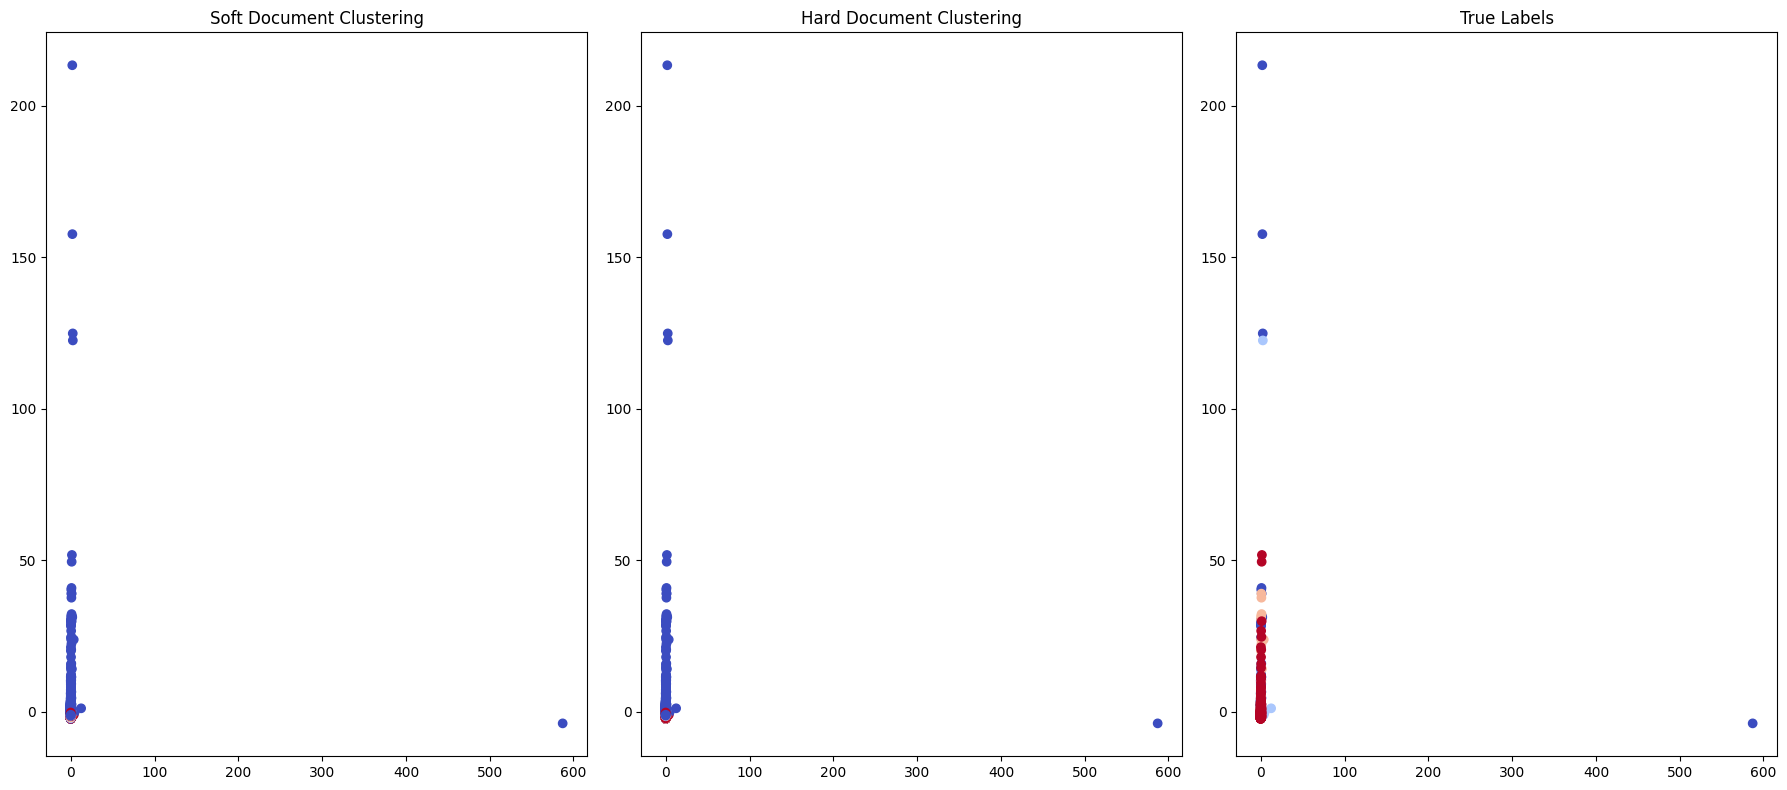

In [11]:
# Initializing the library for PCA
from sklearn.decomposition import PCA
from matplotlib import pyplot as plt

#Performing pca
pca = PCA(n_components=2)
_2D_features = pca.fit_transform(features.toarray())


_, axs = plt.subplots(1, 3, figsize=(18, 8), tight_layout=True)

## plot the soft EM prediction after being PCA
axs[0].scatter(x=_2D_features[:,0],y=_2D_features[:,1], c=pred_soft, cmap='coolwarm')
axs[0].set_title('Soft Document Clustering')

## plot the hard EM prediction after being PCA

axs[1].scatter(x=_2D_features[:,0],y=_2D_features[:,1], c=pred_hard, cmap='coolwarm')
axs[1].set_title('Hard Document Clustering')

## plot the original data after being PCA
axs[2].scatter(x=_2D_features[:,0],y=_2D_features[:,1], c=docs.label.cat.codes, cmap='coolwarm')
axs[2].set_title('True Labels')
plt.show()

We can see from the plot that the spread of the data between the hard EM and soft EM, there's not much a difference between them. This could have been caused by originally, the cluster have a high dimension count that when it's dimensionally reduced, the spread looks condensed into one point. Not helping is that there's clearly some outlier from the data which makes the data should have originally spreaded equally is condensed so that the outlier could be shown.

From the graph too, we can see that the labeling color is different from both the hard and soft EM compared to the true label. By theory, the main advantage of the hard EM is better efficiency for the computational power compared to the soft EM because for hard EM. The responsibility is directly assigned to the cluster with the higher probability. Therefore the responsibility is not probability for each cluster but entirely on the cluster with the highest responsibility. This lowers the computational power needed to do the hard EM algorithm compared to soft EM. But because soft EM assign probability for each cluster. It gives soft EM advantage when modeling more complex model because it enables the document to be placed on multiple clusters. Therefore soft EM should generally perform better than hard EM.

In this case, we can see when peeking at the prediction result, the result from hard EM and soft EM is roughly the same. From above explanation, we can see how it make sense because when hard EM can separate the document into cluster well enough, the soft EM would also perform similarly to the hard EM. This is why both result are roughly the same. It's because that since hard EM is the more simpler approach to document clustering, when hard EM is able to separate the document well enough to the cluster. Soft EM would generally also perform well.

One point of discussion in this algorithm, because smoothing is used to avoid 0/0 error because python default to round the decimals into 0 because the decimals is too big because of the formula. The smoothing made the prediction become skewed into a label, to remedy this aspect. The decimal library can be used but it would also make the algorithm more complex. 